<Axes: >

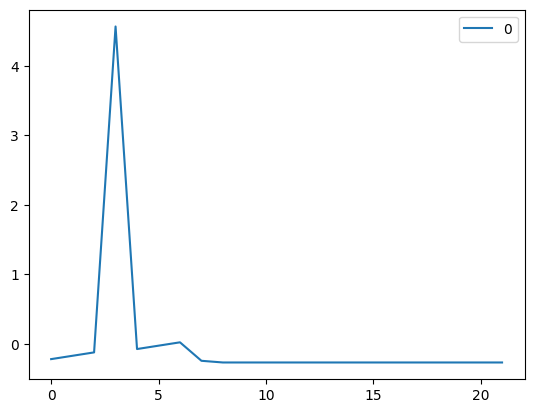

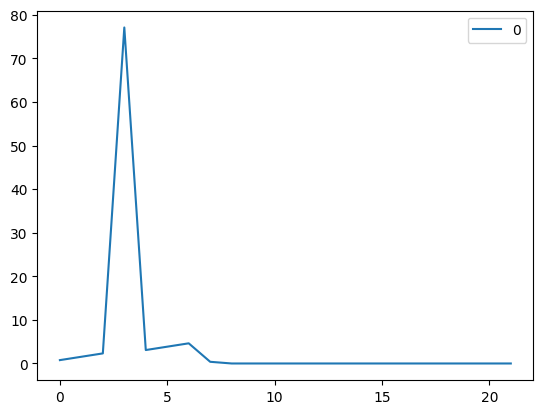

In [13]:
from sklearn.preprocessing import StandardScaler, RobustScaler
import numpy as np
import pandas as pd

# Criando um conjunto de dados com um outlier
X = np.array([[10], [20], [30], [1000], [40], [50], [60],[5],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]])

# Criando os scalers
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Aplicando as transformações
X_standard = pd.DataFrame(standard_scaler.fit_transform(X))
X_robust = pd.DataFrame(1.349*robust_scaler.fit_transform(X))

# Comparando os resultados
X_standard.plot()
X_robust.plot()



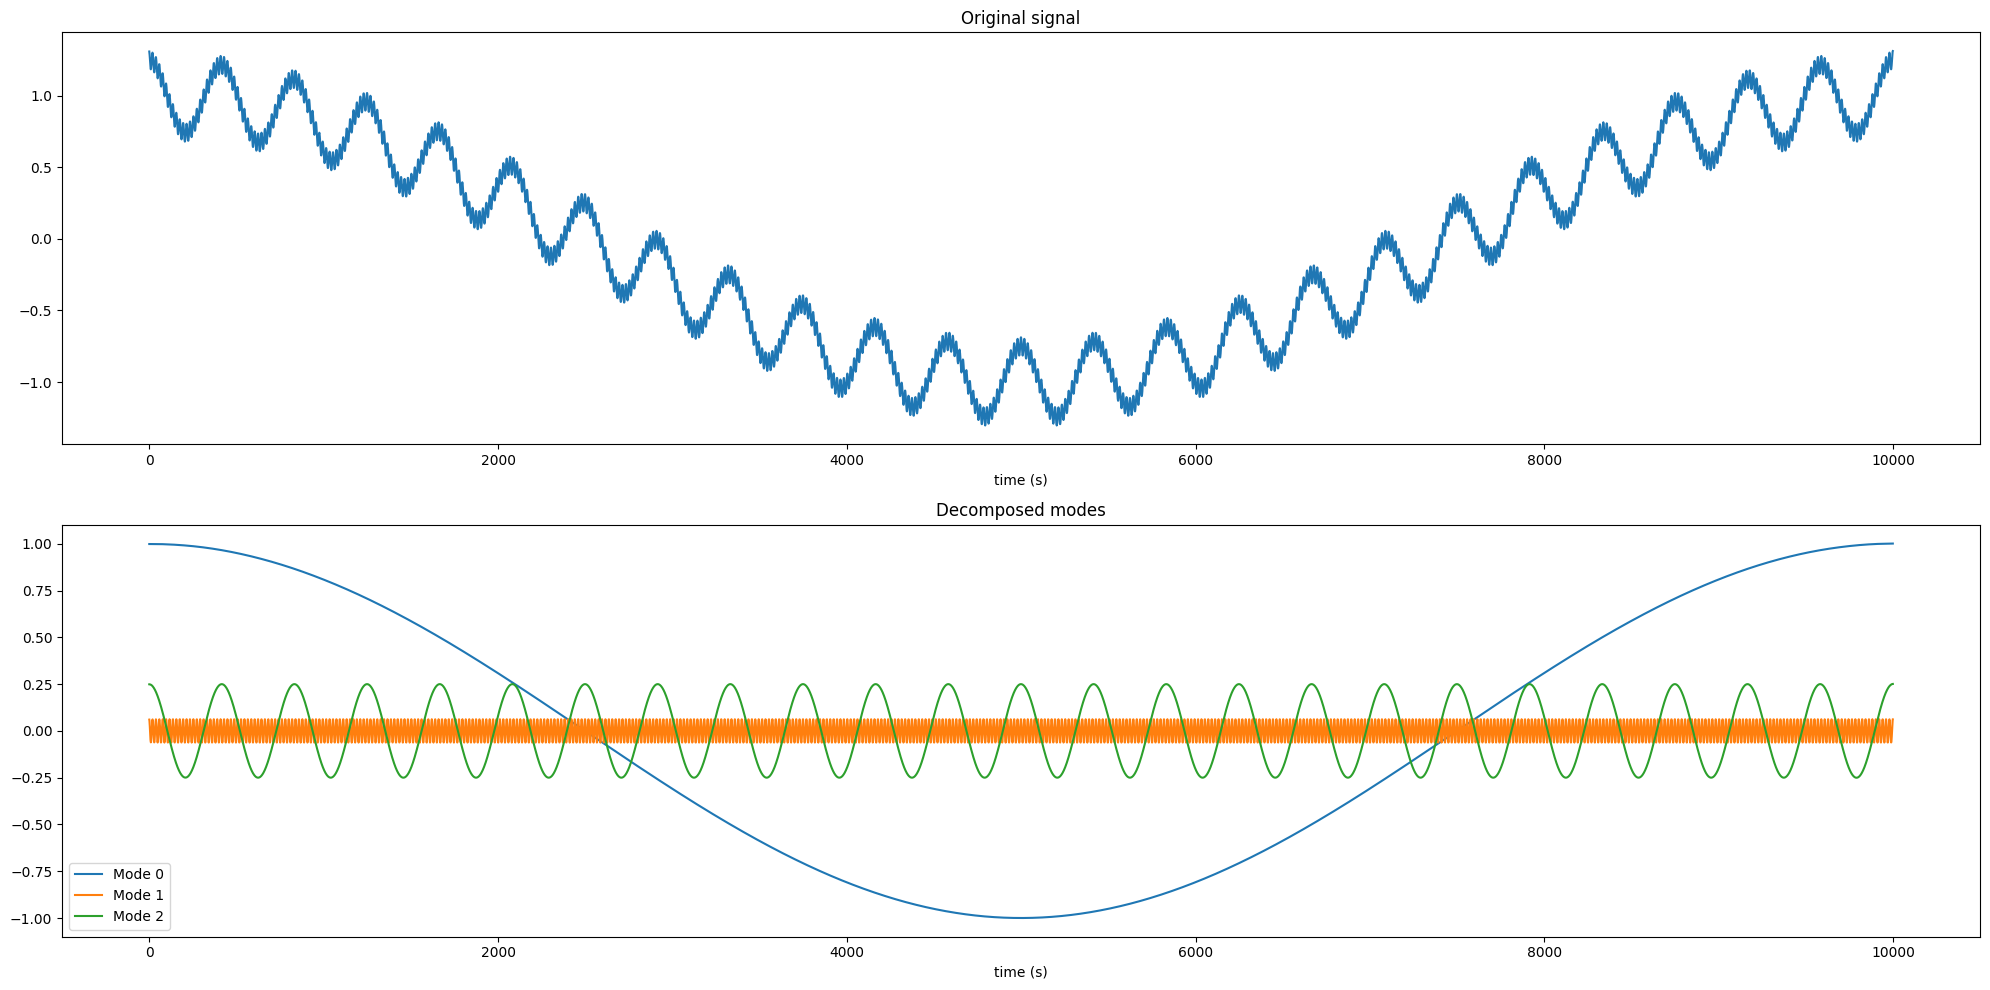

In [56]:
#%% Simple example: generate signal with 3 components + noise
import numpy as np
import matplotlib.pyplot as plt
from sktime.libs.vmdpy import VMD

# Time Domain 0 to T
T = 10000
fs = 1 / T
t = np.arange(1, T + 1) / T
freqs = 2 * np.pi * (t - 0.5 - fs) / (fs)

# center frequencies of components
f_1 = 1
f_2 = 24
f_3 = 512

# modes
v_1 = np.cos(2 * np.pi * f_1 * t)
v_2 = 1 / 4 * (np.cos(2 * np.pi * f_2 * t))
v_3 = 1 / 16 * (np.cos(2 * np.pi * f_3 * t))

signal = v_1 + v_2 + v_3 #+ 0.1 * np.random.randn(t.size)

# some sample parameters for VMD
alpha = 20000  # moderate bandwidth constraint
tau = 0  # noise-tolerance (no strict fidelity enforcement)
K = 3  # 4 modes
DC = 0  # no DC part imposed
init = 1  # initialize omegas uniformly
tol = 1e-7

# Run VMD
u, u_hat, omega = VMD(signal, alpha, tau, K, DC, init, tol)

# Visualize decomposed modes
plt.figure(figsize=(20,10))
plt.subplot(2, 1, 1)
plt.plot(signal)
plt.title("Original signal")
plt.xlabel("time (s)")
plt.subplot(2, 1, 2)
plt.plot(u.T)
plt.title("Decomposed modes")
plt.xlabel("time (s)")
plt.legend(["Mode %d" % m_i for m_i in range(u.shape[0])])
plt.tight_layout()


<Axes: >

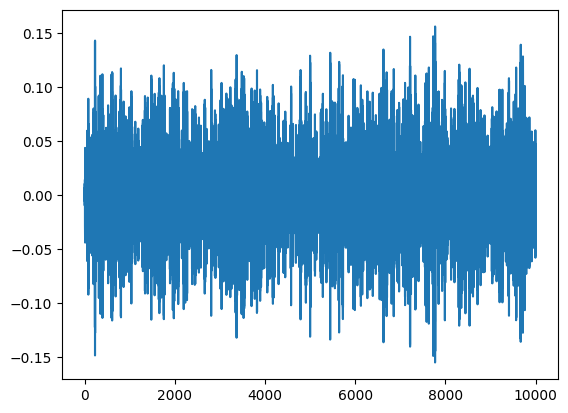

In [35]:
U = pd.DataFrame(u.T)
U[4].plot()

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>],
       [<Axes: title={'center': '4'}>, <Axes: >]], dtype=object)

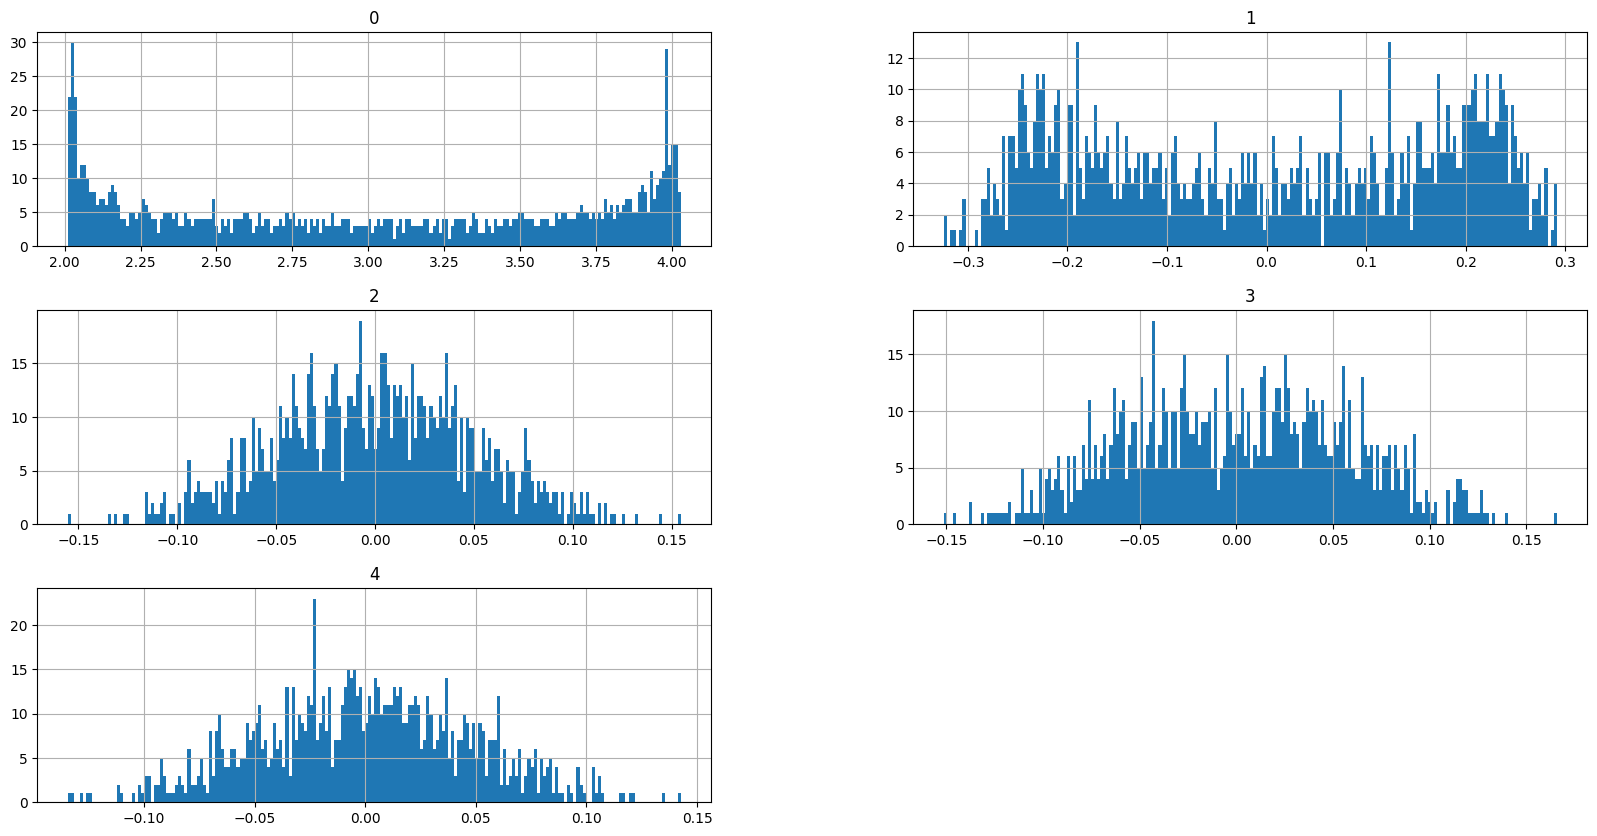

In [26]:
U.hist(figsize=(20,10),bins=200)